# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** I completed this version without generative AI

**Date:** 09/02/2026

**QUESTION 1A**

In [3]:
pip install pandas

In [17]:
# Your Phase 1 solution to the problem goes here.

import pandas as pd

df_air = pd.read_csv("airbnb_hw.csv")
df_air.head(10)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
5,1039,7/25/2008,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
6,1783,8/12/2008,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
7,2078,8/15/2008,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0
8,2339,8/20/2008,East Village Cocoon: 2 Bedroom Flat,Manhattan,Apartment,90.0,Entire home/apt,10009.0,2.0,1,95,270,90.0
9,2339,8/20/2008,Lovely 2 Bedroom East Village Nest,Manhattan,Apartment,95.0,Entire home/apt,10009.0,2.0,1,23,290,96.0


In [18]:
df_air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  object 
 12  Review Scores Rating        22155 non-null  float64
dtypes: float64(4), int64(3), object

In [20]:
df_air['Price'] = df_air['Price'].astype(str).str.replace(',', '', regex=False)
df_air['Price'] = df_air['Price'].astype(str).str.replace('$', '', regex=False)
df_air['Price'] = pd.to_numeric(df_air['Price'], errors='coerce')

n_missing_price = df_air['Price'].isnull().sum()
print(n_missing_price)

0


1) Cleaning Decisions

When values in the price column exceed three digits, formatting adds commas, which would cause Pandas to read price as an object, specifically a string, instead of a numeric value. The same effect would happen if there are any currency indicators before the actual price value, so I chose to strip both commas and dollar symbols from the column.

Since the price column is defined as a string, it should also be converted to a numeric variable so that any missing values will show up as NaN and not impact data analysis/visualization in the future.

2) Number of Missing Values

After cleaning, I'm left with 0 missing values in the price column

**QUESTION 1B**

In [15]:
import pandas as pd

df_pol = pd.read_csv("mn_police_use_of_force.csv")
df_pol.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [28]:
# checking subject_injury data to get Yes/No/NaN counts
print(df_pol["subject_injury"].value_counts(dropna=False))

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64


In [43]:
# calculating missing data proportion
prop_missing = (9849/(9848+1631+1446)*100)
print(f"Proportion of missing values:{prop_missing:.4f}")

# replacing any NaN values with No, under the assumption that if an injury status was not documented, it did not happen
df_pol["subject_injury_clean"] = df_pol["subject_injury"].fillna("No")

Proportion of missing values:76.2012


In [44]:
crosstab = pd.crosstab(df_pol['force_type'], df_pol['subject_injury_clean'], )
print(crosstab,"\n")

# new cross-tabulation with the percentage of No to Yes to better understand the data patterns
crosstab_ratio = pd.crosstab(
    df_pol["force_type"],
    df_pol["subject_injury_clean"],
    normalize="index",  # showing ratio missing
) * 100   # converting from decimal to percentage
print(crosstab_ratio.round(4)) # reducing decimal places shown

subject_injury_clean           No   Yes
force_type                             
Baton                           2     2
Bodily Force                 8144  1286
Chemical Irritant            1552    41
Firearm                         2     0
Gun Point Display              60    44
Improvised Weapon             108    40
Less Lethal                    87     0
Less Lethal Projectile          1     2
Maximal Restraint Technique   170     0
Police K9 Bite                 33    44
Taser                        1135   172 

subject_injury_clean               No      Yes
force_type                                    
Baton                         50.0000  50.0000
Bodily Force                  86.3627  13.6373
Chemical Irritant             97.4262   2.5738
Firearm                      100.0000   0.0000
Gun Point Display             57.6923  42.3077
Improvised Weapon             72.9730  27.0270
Less Lethal                  100.0000   0.0000
Less Lethal Projectile        33.3333  66.6667
Maximal 

1) Missing Values Proportion

Over 75% of the subject_injury values were missing in the dataset. This proportion could be a concern if officers are deciding to not log injuries when they are a result of extreme/uneccessary physical measures. Such decision could have been made to protect their work status or avoid reprecussions.

However, the missing values proportion could also not be a concern under the assumption that officers simply didn't make a record of subject injury if it didn't occur. This assumption greatly increases the number of "No's".

2) Patterns of Missing Data

I decided to do a second cross tabulation that instead shows the percentage of No/Yes values to more clearly compare the data. Once again with the assumption that unrecorded values indicate a lack of subject injury, we can see that there are higher ratios of missingness for lower-impact and common force tactics like "Less Lethal" and "Bodily Force", as well as for the most extreme force types like "Maximal Restraint Technique" and Chemical Irritant". For the lower-impact types, it could be since officers didn't find the need to log  injuries unless specifically asked it. For the higher-impact injuries, the missingness/no value proportions make sense since officers likely don't have to use extreme tactics very often.

**QUESTION 2**

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_shark = pd.read_excel("GSAF5.xls")
df_shark.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Min Year: 0.0, Max Year: 2026.0


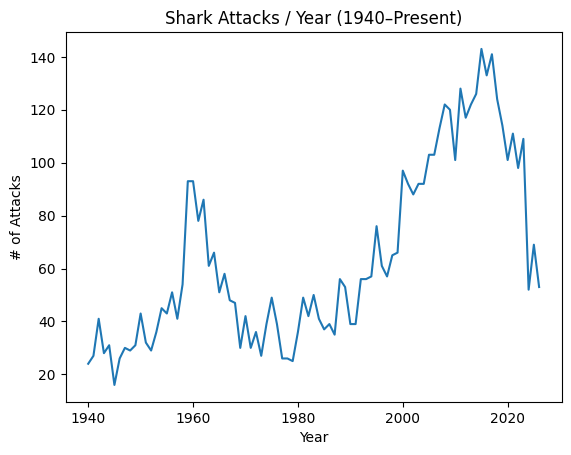

In [70]:
# removing empty columns
df_shark = df_shark.dropna(how="all", axis=1)

# range of all years in dataset
print(
    f"Min Year: {df_shark['Year_Clean'].min()}, Max Year: {df_shark['Year_Clean'].max()}"
)

# ensuring all year values are numeric
df_shark["Year_Clean"] = pd.to_numeric(df_shark["Year"], errors="coerce")

# removing attacks before 1940
df_1940 = df_shark[df_shark["Year_Clean"] >= 1940].copy()

# plotting attacks to see trends
attacks = df_1940.groupby("Year_Clean").size()
plt.figure()
attacks.plot()
plt.title("Shark Attacks / Year (1940–Present)")
plt.xlabel("Year")
plt.ylabel("# of Attacks")
plt.show()

1) Range of Year Values

The range of years in the dataset starts at "0", which likely means that the data includes records of attacks from centuries ago. It ends at 2026, so the dataset is still updated.

2) Attack Trends

Shark attacks have had a net increase since 1940, which could be due to the increased number of human settlement and activity in coastal areas as well as improved accuracy in reporting attacks that occur since global communication has increased significantly since 1940. However, there has been a significant drop of attacks since roughly 2015. The low number of attacks around the COVID-19 pandemic can be explained by the overall reduction in recreational activities and vacations to coastal areas around that time period.

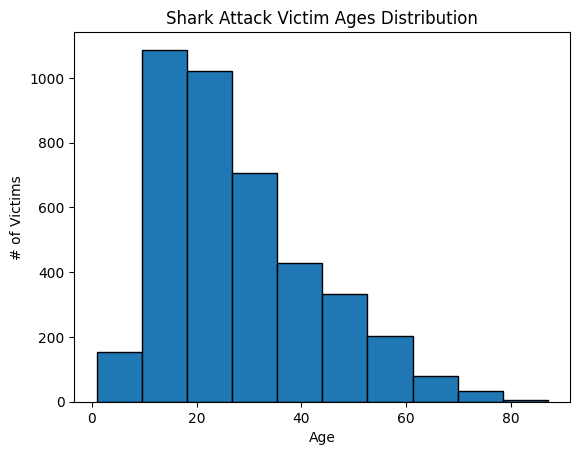

In [88]:
# extracting only the first numerical values in the age column, removing additions like the "+" in 30+, "to" in "20 to 30", and ranges like "teens"
df_shark["Age_Clean"] = df_shark["Age"].astype(str).str.extract(r"(\d+)")[0].astype(float)

# converting to numeric after removing the extra characters
df_shark['Age_Clean'] = pd.to_numeric(df_shark['Age_Clean'], errors='coerce')
ages_clean = df_shark["Age_Clean"].dropna()

# Plot Histogram
plt.figure()
plt.hist(ages_clean, edgecolor="black")
plt.title("Shark Attack Victim Ages Distribution")
plt.xlabel("Age")
plt.ylabel("# of Victims")
plt.show()

In [87]:
# only considering known gender values of M or F and omitting unknowns
known_sex = df_shark[df_shark["Sex"].isin(["M", "F"])]
males = (known_sex["Sex"] == "M").mean()

print(f"Male victims: {males:.3%}")

Male victims: 87.485%


In [95]:
# categorizing all values in type column
def type_clean(val):
    if pd.isna(val):
        return "Unknown"
    val = str(val).strip().title()
    if "Unprovoked" in val:
        return "Unprovoked"
    elif "Provoked" in val:
        return "Provoked"
    else:
        return "Unknown"

df_shark["Type_clean"] = df_shark["Type"].apply(type_clean)

unprovoked = (df_shark["Type_clean"] == "Unprovoked").mean()
print(f"Proportion unprovoked: {unprovoked:.2%}")

Proportion unprovoked: 73.95%


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 3fb6f09b6c6d792451abb26a48b2dbfc2d804666
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. Referencing the attached .ipynb notebook, suggest changes I can make to my solutions (in Phase 1) to the following questions:

Q1. This question provides some practice cleaning variables which have common problems.
For ./data/airbnb_hw.csv, clean the Price variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
For the Minnesota police use of for data, ./data/mn_police_use_of_force.csv, clean the subject_injury variable, handling the NA's; this gives a value Yes when a person was injured by police, and No when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned subject_injury variable with the force_type variable. Are there any patterns regarding when the data are missing?

Q2.
Open the shark attack file using Pandas. It is probably not a csv file, so read_csv won't work.
Drop any columns that do not contain data.
Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
Clean the Age variable and make a histogram of the ages of the victims.
What proportion of victims are male?
Clean the Type variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

### *AI-proposed changes


1. Compute `prop_missing` from code, not a hardcoded number.
2. Reconsider filling `subject_injury` NaNs with `"No"` — use `"Unknown"` instead, given your own crosstab pattern.
3. Reorder the `Year_Clean` creation before you reference it (and always Restart & Run All before submitting).
4. Verify the `dropna(how="all")` step is actually removing columns.
5. Caveat the most recent 1–2 years of shark attack data as likely incomplete rather than a real decline.
6. Handle "months" age entries separately from years.
7. Strip/uppercase `Sex` before filtering to M/F.

** Claude gave me more in-depth feedback, separated by each question, but above I've listed the overall changes. **


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Computing prop_missing using code would be more efficient and I made an error with the values when calculating manually. |
| 2 | Accept | Converting NaNs to "No" makes a pretty big assumption as well as greatly impacts the ratio of "No" to "Yes" subject-injury counts, which effects the analysis I make later on.   |
| 3 | Accept | Restarting and rerunning this block of code would have resulted in an error so I switched the order of the code. |
| 4 | Accept | After double-checking that the dropna(how=all) command was working, I found that no columns were removed. Adding a threshold worked in fixing this error.  |
| 5 | Reject | There is no indicator of a lag in data reporting, especially since attacks in 2026 have already been logged. If Claude's assumption is true, my analysis is still not effected by removing the last two years of data.  |
| 6 | Accept | After looking at the full dataset, there were some values like "18 months" but my previous code would convert that value to "18", meaning "18 years".|
| 7 | Accept | Stripping the whitespace around "M" and "F" slightly changed the male victim percentage calculated, although not by much. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

**QUESTION 1A**

In [96]:
import pandas as pd

df_air = pd.read_csv("airbnb_hw.csv")
df_air.head(10)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
5,1039,7/25/2008,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
6,1783,8/12/2008,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
7,2078,8/15/2008,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0
8,2339,8/20/2008,East Village Cocoon: 2 Bedroom Flat,Manhattan,Apartment,90.0,Entire home/apt,10009.0,2.0,1,95,270,90.0
9,2339,8/20/2008,Lovely 2 Bedroom East Village Nest,Manhattan,Apartment,95.0,Entire home/apt,10009.0,2.0,1,23,290,96.0


In [100]:
df_air.info()

df_air['Price'] = df_air['Price'].astype(str).str.replace(r'[$,]', '', regex=True) # combined what was previously two lines to one line
df_air['Price'] = pd.to_numeric(df_air['Price'], errors='coerce')

n_missing_price = df_air['Price'].isnull().sum()
print("\nMissing prices:", n_missing_price)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  int64  
 12  Review Scores Rating        22155 non-null  float64
dtypes: float64(4), int64(4), object

**QUESTION 1B**

In [102]:
import pandas as pd

df_pol = pd.read_csv("mn_police_use_of_force.csv")
df_pol.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [104]:
# checking subject_injury data to get Yes/No/NaN counts
print(df_pol["subject_injury"].value_counts(dropna=False))

# calculating missing data proportion
prop_missing = df_pol['subject_injury'].isna().mean() * 100
print(f"Proportion of missing values:{prop_missing:.4f}")

# replacing any NaN values with Unknown so that the no-injury rate is not overestimated
df_pol["subject_injury_clean"] = df_pol["subject_injury"].fillna("Unknown")

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64
Proportion of missing values:76.1934


In [105]:
crosstab = pd.crosstab(df_pol['force_type'], df_pol['subject_injury_clean'], )
print(crosstab,"\n")

# new cross-tabulation with the percentage of No to Yes to better understand the data patterns
crosstab_ratio = pd.crosstab(
    df_pol["force_type"],
    df_pol["subject_injury_clean"],
    normalize="index",  # showing ratio missing
) * 100   # converting from decimal to percentage
print(crosstab_ratio.round(4)) # reducing decimal places shown

subject_injury_clean           No  Unknown   Yes
force_type                                      
Baton                           0        2     2
Bodily Force                 1093     7051  1286
Chemical Irritant             131     1421    41
Firearm                         2        0     0
Gun Point Display              33       27    44
Improvised Weapon              34       74    40
Less Lethal                     0       87     0
Less Lethal Projectile          1        0     2
Maximal Restraint Technique     0      170     0
Police K9 Bite                  2       31    44
Taser                         150      985   172 

subject_injury_clean               No   Unknown      Yes
force_type                                              
Baton                          0.0000   50.0000  50.0000
Bodily Force                  11.5907   74.7720  13.6373
Chemical Irritant              8.2235   89.2028   2.5738
Firearm                      100.0000    0.0000   0.0000
Gun Point Display  

**QUESTION 2**

In [106]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_shark = pd.read_excel("GSAF5.xls")
df_shark.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
# removing empty columns
df_shark = df_shark.dropna(axis=1, thresh=10)
df_shark.head()


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Fatal Y/N,Time,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,N,1330hrs,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,N,1700hrs,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,N,?,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,N,1615hrs,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,N,1300hrs,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN


Min Year: 0.0, Max Year: 2026.0


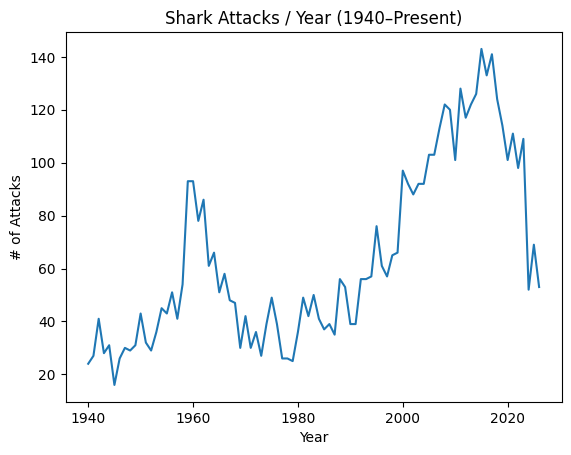

In [114]:
# ensuring all year values are numeric
df_shark["Year_Clean"] = pd.to_numeric(df_shark["Year"], errors="coerce")

# range of all years in dataset
print(
    f"Min Year: {df_shark['Year_Clean'].min()}, Max Year: {df_shark['Year_Clean'].max()}"
)

# removing attacks before 1940
df_1940 = df_shark[df_shark["Year_Clean"] >= 1940].copy()

# plotting attacks to see trends
attacks = df_1940.groupby("Year_Clean").size()
plt.figure()
attacks.plot()
plt.title("Shark Attacks / Year (1940–Present)")
plt.xlabel("Year")
plt.ylabel("# of Attacks")
plt.show()

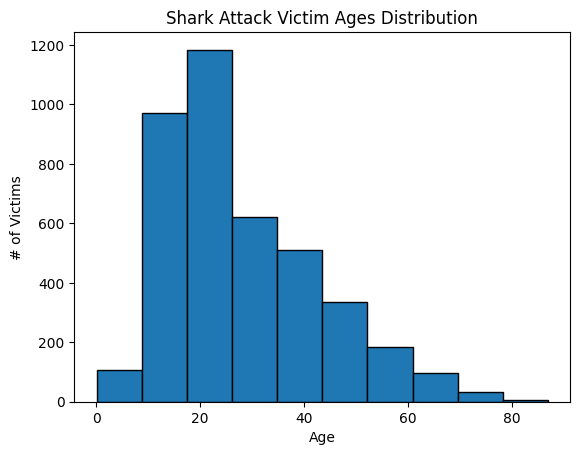

In [115]:
# extracting only the first numerical values in the age column, removing additions like the "+" in 30+, "to" in "20 to 30", and ranges like "teens"
age_str = df_shark["Age"].astype(str)
is_months = age_str.str.contains("month", case=False, na=False)
df_shark["Age_Clean"] = age_str.str.extract(r"(\d+)")[0].astype(float)
df_shark.loc[is_months, "Age_Clean"] = df_shark.loc[is_months, "Age_Clean"] / 12

# converting to numeric after removing the extra characters
df_shark['Age_Clean'] = pd.to_numeric(df_shark['Age_Clean'], errors='coerce')
ages_clean = df_shark["Age_Clean"].dropna()

# Plot Histogram
plt.figure()
plt.hist(ages_clean, edgecolor="black")
plt.title("Shark Attack Victim Ages Distribution")
plt.xlabel("Age")
plt.ylabel("# of Victims")
plt.show()

In [116]:
# only considering known gender values of M or F and omitting unknowns
sex_clean = df_shark["Sex"].astype(str).str.strip().str.upper()
known_sex = df_shark[sex_clean.isin(["M", "F"])]
males = (known_sex["Sex"] == "M").mean()

print(f"Male victims: {males:.3%}")

Male victims: 87.337%


In [117]:
# categorizing all values in type column
def type_clean(val):
    if pd.isna(val):
        return "Unknown"
    val = str(val).strip().title()
    if "Unprovoked" in val:
        return "Unprovoked"
    elif "Provoked" in val:
        return "Provoked"
    else:
        return "Unknown"

df_shark["Type_clean"] = df_shark["Type"].apply(type_clean)

unprovoked = (df_shark["Type_clean"] == "Unprovoked").mean()
print(f"Proportion unprovoked: {unprovoked:.2%}")

Proportion unprovoked: 73.95%


### *Reflection on AI assistance
In your own words without generative AI.

Using AI to check my solution was helpful because it detected the small errors I made as well as helped a bit with making my code more concise. It also presented a different logic to consider when cleaning, specifically my decision to convert unknown values to "No" in the police dataset. I initially did not think that making a third response type of "Unknown" was allowed according to the assignment instructions, but after re-reading them, I found that making an Unknown column still fit the instructions as well as would be more accurate for analyzing the data afterwards.

A limitation of AI is that it at times overcomplicated the responses to question parts, when the solution could have been reached quicker by thinking about it plainly. An example of this is Claude's rationale to omit the last two years of data from the shark attack trend figure. While it is a potential consideration, there is no need to omit data without actual evidence that the dataset hasn't been fully updated.